In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [251]:
def translation_matrix(tx,ty):
    return np.array([[1,0,tx] , [0,1,ty] , [0,0,1]])

def rotational_matrix(cos_a,sin_a):
    return np.array([[cos_a , -sin_a , 0] , [sin_a , cos_a , 0] , [0,0,1]])

def scaling_matrix(sx,sy):
    return np.array([ [sx,0,0] , [0,sy,0] , [0,0,1] ])

def point_matrix(point):
    return np.array([point[0],point[1],1])

def reflection_matrix_on_x():
    return np.array([ [1,0,0] , [0,-1,0] , [0,0,1]])
def reflection_matrix_on_y():
    return np.array([ [-1,0,0] , [0,1,0] , [0,0,1]])
def reflection_matrix_on_origin():
    return np.array([ [-1,0,0] , [0,-1,0] , [0,0,1]])
def shearing_along_x(shx):
    return np.array([[1,shx,0] , [0,1,0] , [0,0,1] ])
def shearing_along_y(shy):
    return np.array([[1,0,0] , [shy,1,0] , [0,0,1] ])

In [252]:
def transform_one_point(homo_matrix , point):
    p_matrix = np.array([point[0],point[1],1])
    transformed_matrix = np.matmul(homo_matrix , p_matrix)
    transformed_point = transformed_matrix[:2]
    return transformed_point

def transformation(homo_matrix , tringle):
    return [transform_one_point(homo_matrix , i) for i in tringle]
    

In [253]:
def get_points(polygon):
    xarr = [i[0] for i in polygon]
    xarr.append(xarr[0])
    yarr = [i[1] for i in polygon]
    yarr.append(yarr[0])
    return [xarr , yarr]

In [254]:
def draw(parr , tarr,opr):
    plt.plot(parr[0] , parr[1], marker='o', label = 'original')
    plt.plot(tarr[0] , tarr[1], marker='o', label = opr)
    plt.legend()
    plt.axis("equal")
    plt.grid(True)
    plt.show()

In [255]:
tringle = np.array([(20, 20), (60, 20), (40, 60)])
parr = get_points(tringle)

In [256]:
square = np.array([(10, 10), (50, 10), (50, 50), (10, 50)])
sqr = get_points(square)

In [257]:
tv = [30,25]
tm = translation_matrix(tv[0] , tv[1])
translated_points = transformation(tm,tringle)
tarr = get_points(translated_points)

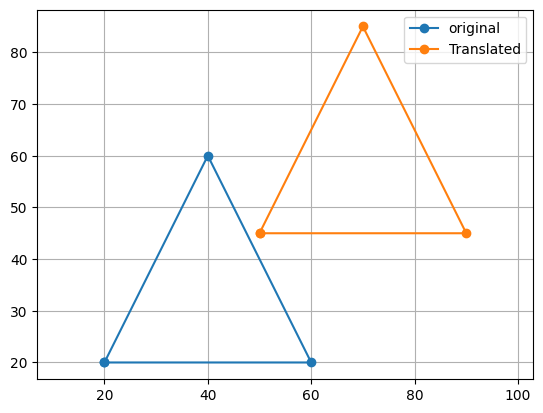

In [258]:
draw(parr , tarr,'Translated')

In [259]:
angle = 60
cos_a = np.cos(np.deg2rad(angle))
sin_a = np.sin(np.deg2rad(angle))
rm = rotational_matrix(cos_a , sin_a)

In [260]:
rotation_points = transformation(rm,tringle)
tarr = get_points(rotation_points)

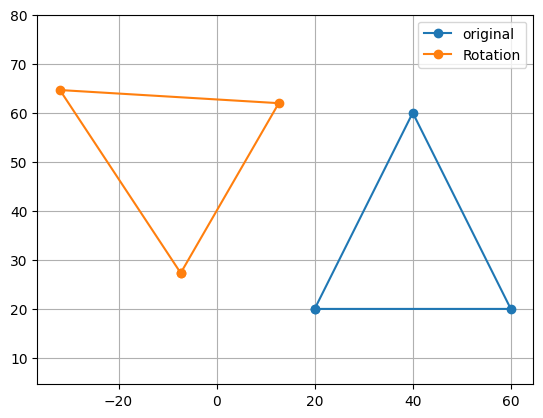

In [261]:
draw(parr,tarr,'Rotation')

In [262]:
scalers = [2,1.5]
sm = scaling_matrix(scalers[0] , scalers[1])
sm.shape

(3, 3)

In [263]:
scaled_points = transformation(sm,tringle)
tarr = get_points(scaled_points)

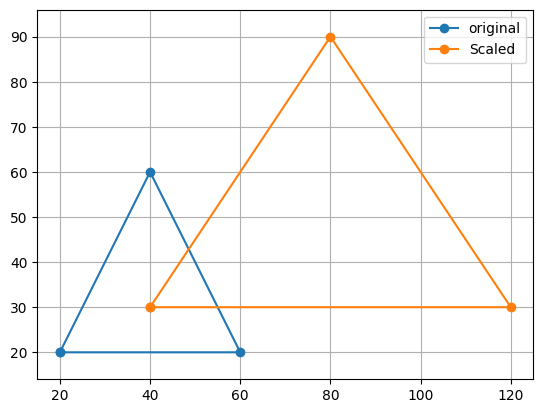

In [264]:
draw(parr,tarr,'Scaled')

In [265]:
rm = reflection_matrix_on_x()
translated_points = transformation(rm,tringle)
tarr = get_points(translated_points)
translated_points

[array([ 20, -20]), array([ 60, -20]), array([ 40, -60])]

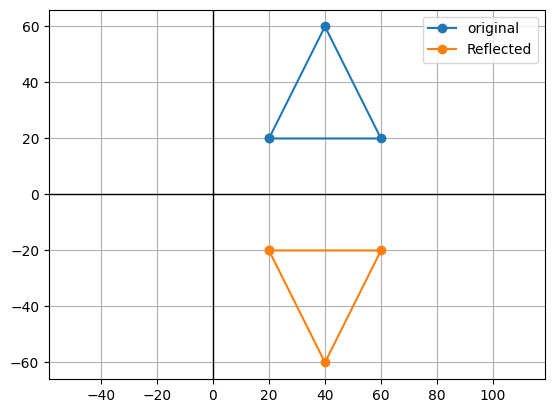

In [266]:
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
draw(parr , tarr,'Reflected')

In [267]:
rm = reflection_matrix_on_x()
reflected_points = transformation(rm,tringle)
tarr = get_points(reflected_points)

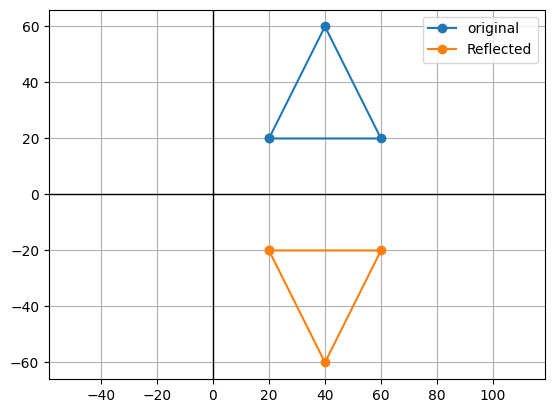

In [268]:
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
draw(parr , tarr,'Reflected')

In [269]:
rm = reflection_matrix_on_y()
reflected_points = transformation(rm,tringle)
tarr = get_points(reflected_points)

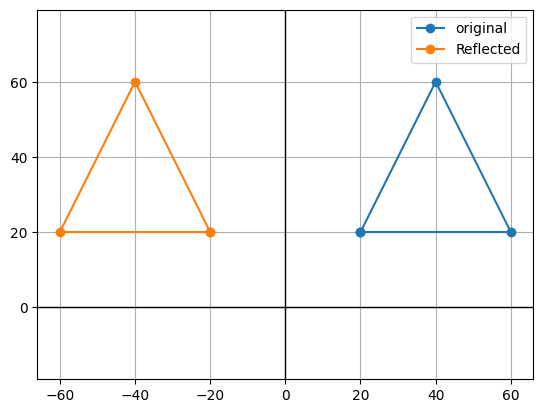

In [270]:
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
draw(parr , tarr,'Reflected')

In [271]:
rm = reflection_matrix_on_origin()
reflected_points = transformation(rm,tringle)
tarr = get_points(reflected_points)

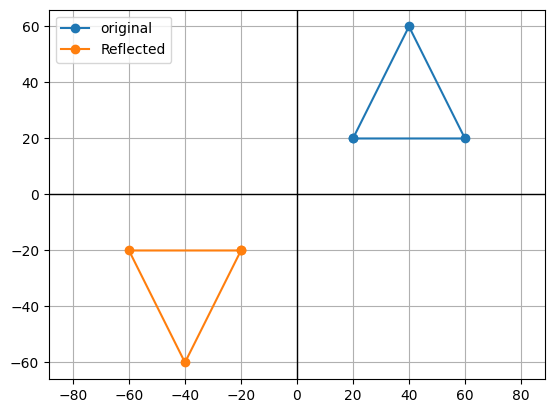

In [272]:
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
draw(parr , tarr,'Reflected')

In [273]:
angle = -1
shx = np.deg2rad(angle)
shxm = shearing_along_x(shx)
sheared_points = transformation(shxm , square)
tarr = get_points(sheared_points)

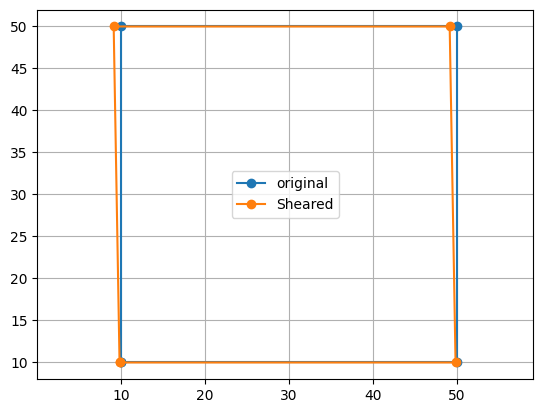

In [274]:
draw(sqr,tarr,'Sheared')

In [275]:
angle = 1.5
shy = np.deg2rad(angle)
shym = shearing_along_y(shy)
sheared_points = transformation(shym , square)
tarr = get_points(sheared_points)

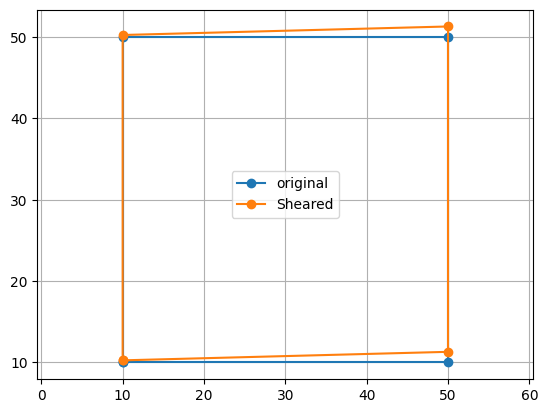

In [276]:
draw(sqr,tarr,'Sheared')